In [ ]:
!nvidia-smi

!pip uninstall -y numpy ultralytics roboflow -q

# Install pinned, compatible versions together (avoids resolver conflicts)
!pip install numpy==1.26.4 ultralytics==8.3.59 roboflow opencv-python-headless -q

# Restart the kernel to load the new versions cleanly
import os
os.kill(os.getpid(), 9)

Sat Sep  5 06:58:18 2026       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 580.82.07              Driver Version: 580.82.07      CUDA Version: 13.0     |
+-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  Tesla T4                       Off |   00000000:00:04.0 Off |                    0 |
| N/A   70C    P8             13W /   70W |       0MiB /  15360MiB |      0%      Default |
|                                         |                        |                  N/A |
+-----------------------------------------+-----

In [ ]:

# Run this AFTER the kernel restarts (run it manually, second)

import os
HOME = os.getcwd()

from IPython import display
display.clear_output()

!yolo settings sync=False
import ultralytics
ultralytics.checks()

from ultralytics import YOLO
from IPython.display import display, Image
from roboflow import Roboflow
import torch
import torch.nn as nn

from google.colab import drive
drive.mount('/content/drive')

print("✅ Environment ready. HOME =", HOME)

Ultralytics 8.3.59 🚀 Python-3.13.15 torch-2.11.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
Setup complete ✅ (2 CPUs, 12.7 GB RAM, 47.7/112.6 GB disk)
Mounted at /content/drive
✅ Environment ready. HOME = /content


In [ ]:
!pip install roboflow

from roboflow import Roboflow
rf = Roboflow(api_key="YOUR_ACTUAL_KEY")
project = rf.workspace("nurs-workspace-uplim").project("wound-cw2to")
version = project.version(6)
dataset = version.download("yolov8")

loading Roboflow workspace...
loading Roboflow project...



Extracting Dataset Version Zip to wound-6 in yolov8:: 100%|██████████| 3005/3005 [00:00<00:00, 4456.47it/s]


In [ ]:

# Print per-class counts for train/valid/test — ORIGINAL dataset

from collections import Counter

root = dataset.location  # e.g. /content/wound-5

with open(os.path.join(root, "data.yaml")) as f:
    import yaml
    data_yaml = yaml.safe_load(f)
class_names = data_yaml['names']
print("Classes:", class_names, "\n")

def get_class_id(label_path):
    with open(label_path) as f:
        line = f.readline().strip()
        return int(line.split()[0]) if line else None  # None = empty label file

for split in ["train", "valid", "test"]:
    img_dir = os.path.join(root, split, "images")
    lbl_dir = os.path.join(root, split, "labels")

    if not os.path.exists(img_dir):
        print(f"{split}: folder not found\n")
        continue

    total_images = len(os.listdir(img_dir))
    class_counts = Counter()
    empty_count = 0
    missing_label_count = 0

    for img_name in os.listdir(img_dir):
        base = os.path.splitext(img_name)[0]
        lbl_path = os.path.join(lbl_dir, base + ".txt")

        if not os.path.exists(lbl_path):
            missing_label_count += 1
            continue

        if os.path.getsize(lbl_path) == 0:
            empty_count += 1
            continue

        cid = get_class_id(lbl_path)
        if cid is not None:
            class_counts[cid] += 1

    print(f"=== {split.upper()} ===")
    print(f"Total images: {total_images}")
    for cid in sorted(class_names.keys()) if isinstance(class_names, dict) else range(len(class_names)):
        cname = class_names[cid]
        print(f"  {cname}: {class_counts[cid]}")
    print(f"  Empty label files (no objects): {empty_count}")
    print(f"  Missing label files entirely: {missing_label_count}")
    print()

Classes: ['mild', 'normal', 'severe'] 

=== TRAIN ===
Total images: 1140
  mild: 480
  normal: 180
  severe: 480
  Empty label files (no objects): 0
  Missing label files entirely: 0

=== VALID ===
Total images: 180
  mild: 60
  normal: 60
  severe: 60
  Empty label files (no objects): 0
  Missing label files entirely: 0

=== TEST ===
Total images: 180
  mild: 60
  normal: 60
  severe: 60
  Empty label files (no objects): 0
  Missing label files entirely: 0



In [ ]:

# Simple augmentation: brightness/contrast/noise only

import os, cv2, random, yaml, shutil

!pip install -q albumentations opencv-python-headless
import albumentations as A

root = dataset.location

with open(os.path.join(root, "data.yaml")) as f:
    data_yaml = yaml.safe_load(f)
class_names = data_yaml['names']
normal_id = [i for i, n in enumerate(class_names) if n.lower() == "normal"][0]
print("Normal class id:", normal_id)

random.seed(42)

# pixel-only transforms — never touch bounding boxes, so labels stay valid
transform = A.Compose([
    A.RandomBrightnessContrast(brightness_limit=0.2, contrast_limit=0.2, p=0.9),
    A.GaussNoise(p=0.3),
])

def augment_image_only(img_path, out_img_path):
    image = cv2.imread(img_path)
    result = transform(image=image)
    cv2.imwrite(out_img_path, result['image'])

print("Setup done.")

Normal class id: 1
Setup done.


In [ ]:

train_img_dir = os.path.join(root, "train", "images")
train_lbl_dir = os.path.join(root, "train", "labels")

def get_class_id(label_path):
    with open(label_path) as f:
        line = f.readline().strip()
        return int(line.split()[0]) if line else None

normal_train_files = []
for img_name in os.listdir(train_img_dir):
    base = os.path.splitext(img_name)[0]
    lbl_path = os.path.join(train_lbl_dir, base + ".txt")
    if os.path.exists(lbl_path) and get_class_id(lbl_path) == normal_id:
        normal_train_files.append((os.path.join(train_img_dir, img_name), lbl_path))

print(f"Normal images in train: {len(normal_train_files)}")

Normal images in train: 180


In [ ]:

# Augment Normal train images: 180 → 480 (add 300)
# Simple pixel-only augmentation — label file is just copied, unchanged

needed = 480 - len(normal_train_files)
print(f"Need to generate: {needed} new augmented Normal images")

for i in range(needed):
    img_path, lbl_path = normal_train_files[i % len(normal_train_files)]
    base = os.path.splitext(os.path.basename(img_path))[0]
    out_img = os.path.join(train_img_dir, f"{base}_aug{i}.jpg")
    out_lbl = os.path.join(train_lbl_dir, f"{base}_aug{i}.txt")

    augment_image_only(img_path, out_img)
    shutil.copy(lbl_path, out_lbl)  # labels unchanged since pixels-only aug doesn't move boxes

print(f"Done. Added {needed} augmented Normal images directly into train/")

Need to generate: 300 new augmented Normal images
Done. Added 300 augmented Normal images directly into train/


In [ ]:

# Summary table: per-class counts across train/valid/test

import pandas as pd
from collections import Counter

def get_class_id(label_path):
    with open(label_path) as f:
        line = f.readline().strip()
        return int(line.split()[0]) if line else None

summary = {cname: {} for cname in class_names}
totals = {}

for split in ["train", "valid", "test"]:
    img_dir = os.path.join(root, split, "images")
    lbl_dir = os.path.join(root, split, "labels")

    counts = Counter()
    for img_name in os.listdir(img_dir):
        base = os.path.splitext(img_name)[0]
        lbl_path = os.path.join(lbl_dir, base + ".txt")
        if os.path.exists(lbl_path) and os.path.getsize(lbl_path) > 0:
            cid = get_class_id(lbl_path)
            if cid is not None:
                counts[cid] += 1

    for cid, cname in enumerate(class_names):
        summary[cname][split.capitalize()] = counts[cid]

    totals[split.capitalize()] = len(os.listdir(img_dir))

df = pd.DataFrame(summary).T
df = df[["Train", "Valid", "Test"]]  # order columns
df["Total"] = df.sum(axis=1)

# add a Total row
total_row = pd.DataFrame({
    "Train": [df["Train"].sum()],
    "Valid": [df["Valid"].sum()],
    "Test": [df["Test"].sum()],
    "Total": [df["Total"].sum()]
}, index=["Total"])

df_final = pd.concat([df, total_row])
print(df_final.to_string())

        Train  Valid  Test  Total
mild      480     60    60    600
normal    480     60    60    600
severe    480     60    60    600
Total    1440    180   180   1800


In [ ]:

# Train YOLOv8s-seg for 20 epochs

!pip install -q ultralytics

from ultralytics import YOLO

yaml_path = os.path.join(root, "data.yaml")
print("Training with:", yaml_path)

model = YOLO("yolov8s-seg.pt")

results = model.train(
    data=yaml_path,
    epochs=20,
    imgsz=640,
    batch=16,
    name="wound_seg_yolov8s",
    patience=20,
    plots=True
)

Training with: /content/wound-6/data.yaml


100%|██████████| 22.8M/22.8M [00:00<00:00, 43.4MB/s]


New https://pypi.org/project/ultralytics/8.4.140 available 😃 Update with 'pip install -U ultralytics'
Ultralytics 8.3.59 🚀 Python-3.13.15 torch-2.11.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
engine/trainer: task=segment, mode=train, model=yolov8s-seg.pt, data=/content/wound-6/data.yaml, epochs=20, time=None, patience=20, batch=16, imgsz=640, save=True, save_period=-1, cache=False, device=None, workers=8, project=None, name=wound_seg_yolov8s, exist_ok=False, pretrained=True, optimizer=auto, verbose=True, seed=0, deterministic=True, single_cls=False, rect=False, cos_lr=False, close_mosaic=10, resume=False, amp=True, fraction=1.0, profile=False, freeze=None, multi_scale=False, overlap_mask=True, mask_ratio=4, dropout=0.0, val=True, split=val, save_json=False, save_hybrid=False, conf=None, iou=0.7, max_det=300, half=False, dnn=False, plots=True, source=None, vid_stride=1, stream_buffer=False, visualize=False, augment=False, agnostic_nms=False, classes=None, retina_masks=False, embed=None, show=F

100%|██████████| 755k/755k [00:00<00:00, 143MB/s]


Overriding model.yaml nc=80 with nc=3

                   from  n    params  module                                       arguments                     
  0                  -1  1       928  ultralytics.nn.modules.conv.Conv             [3, 32, 3, 2]                 
  1                  -1  1     18560  ultralytics.nn.modules.conv.Conv             [32, 64, 3, 2]                
  2                  -1  1     29056  ultralytics.nn.modules.block.C2f             [64, 64, 1, True]             
  3                  -1  1     73984  ultralytics.nn.modules.conv.Conv             [64, 128, 3, 2]               
  4                  -1  2    197632  ultralytics.nn.modules.block.C2f             [128, 128, 2, True]           
  5                  -1  1    295424  ultralytics.nn.modules.conv.Conv             [128, 256, 3, 2]              
  6                  -1  2    788480  ultralytics.nn.modules.block.C2f             [256, 256, 2, True]           
  7                  -1  1   1180672  ultralytics

...

      20/20      4.71G     0.4935     0.8069     0.2672     0.9629         16        640: 100%|██████████| 90/90 [00:38<00:00,  2.34it/s]
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95)     Mask(P          R      mAP50  mAP50-95): 100%|██████████| 6/6 [00:02<00:00,  2.38it/s]

                   all        180        183      0.985      0.978      0.986      0.874      0.985      0.978      0.986      0.861



20 epochs completed in 0.242 hours.
Optimizer stripped from runs/segment/wound_seg_yolov8s/weights/last.pt, 23.8MB
Optimizer stripped from runs/segment/wound_seg_yolov8s/weights/best.pt, 23.8MB

Validating runs/segment/wound_seg_yolov8s/weights/best.pt...
Ultralytics 8.3.59 🚀 Python-3.13.15 torch-2.11.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
YOLOv8s-seg summary (fused): 195 layers, 11,780,761 parameters, 0 gradients, 39.9 GFLOPs


                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95)     Mask(P          R      mAP50  mAP50-95): 100%|██████████| 6/6 [00:03<00:00,  1.63it/s]


                   all        180        183      0.985      0.978      0.986      0.875      0.985      0.978      0.986      0.861
                  mild         60         63      0.967      0.935      0.969      0.856      0.967      0.935      0.969      0.794
                normal         60         60      0.994          1      0.995      0.839      0.994          1      0.995      0.853
                severe         60         60      0.993          1      0.995      0.931      0.993          1      0.995      0.936
Speed: 0.3ms preprocess, 3.7ms inference, 0.0ms loss, 2.8ms postprocess per image
Results saved to runs/segment/wound_seg_yolov8s


Training run folder: runs/segment/wound_seg_yolov8s
Contents: ['train_batch1.jpg', 'train_batch900.jpg', 'val_batch0_labels.jpg', 'val_batch1_pred.jpg', 'train_batch901.jpg', 'BoxP_curve.png', 'weights', 'BoxF1_curve.png', 'labels_correlogram.jpg', 'train_batch0.jpg', 'BoxPR_curve.png', 'train_batch2.jpg', 'train_batch902.jpg', 'args.yaml', 'results.csv', 'MaskF1_curve.png', 'confusion_matrix_normalized.png', 'val_batch2_pred.jpg', 'MaskR_curve.png', 'MaskP_curve.png', 'val_batch1_labels.jpg', 'BoxR_curve.png', 'val_batch2_labels.jpg', 'confusion_matrix.png', 'results.png', 'MaskPR_curve.png', 'labels.jpg', 'val_batch0_pred.jpg']

Training results (loss, precision, recall, mAP over epochs):


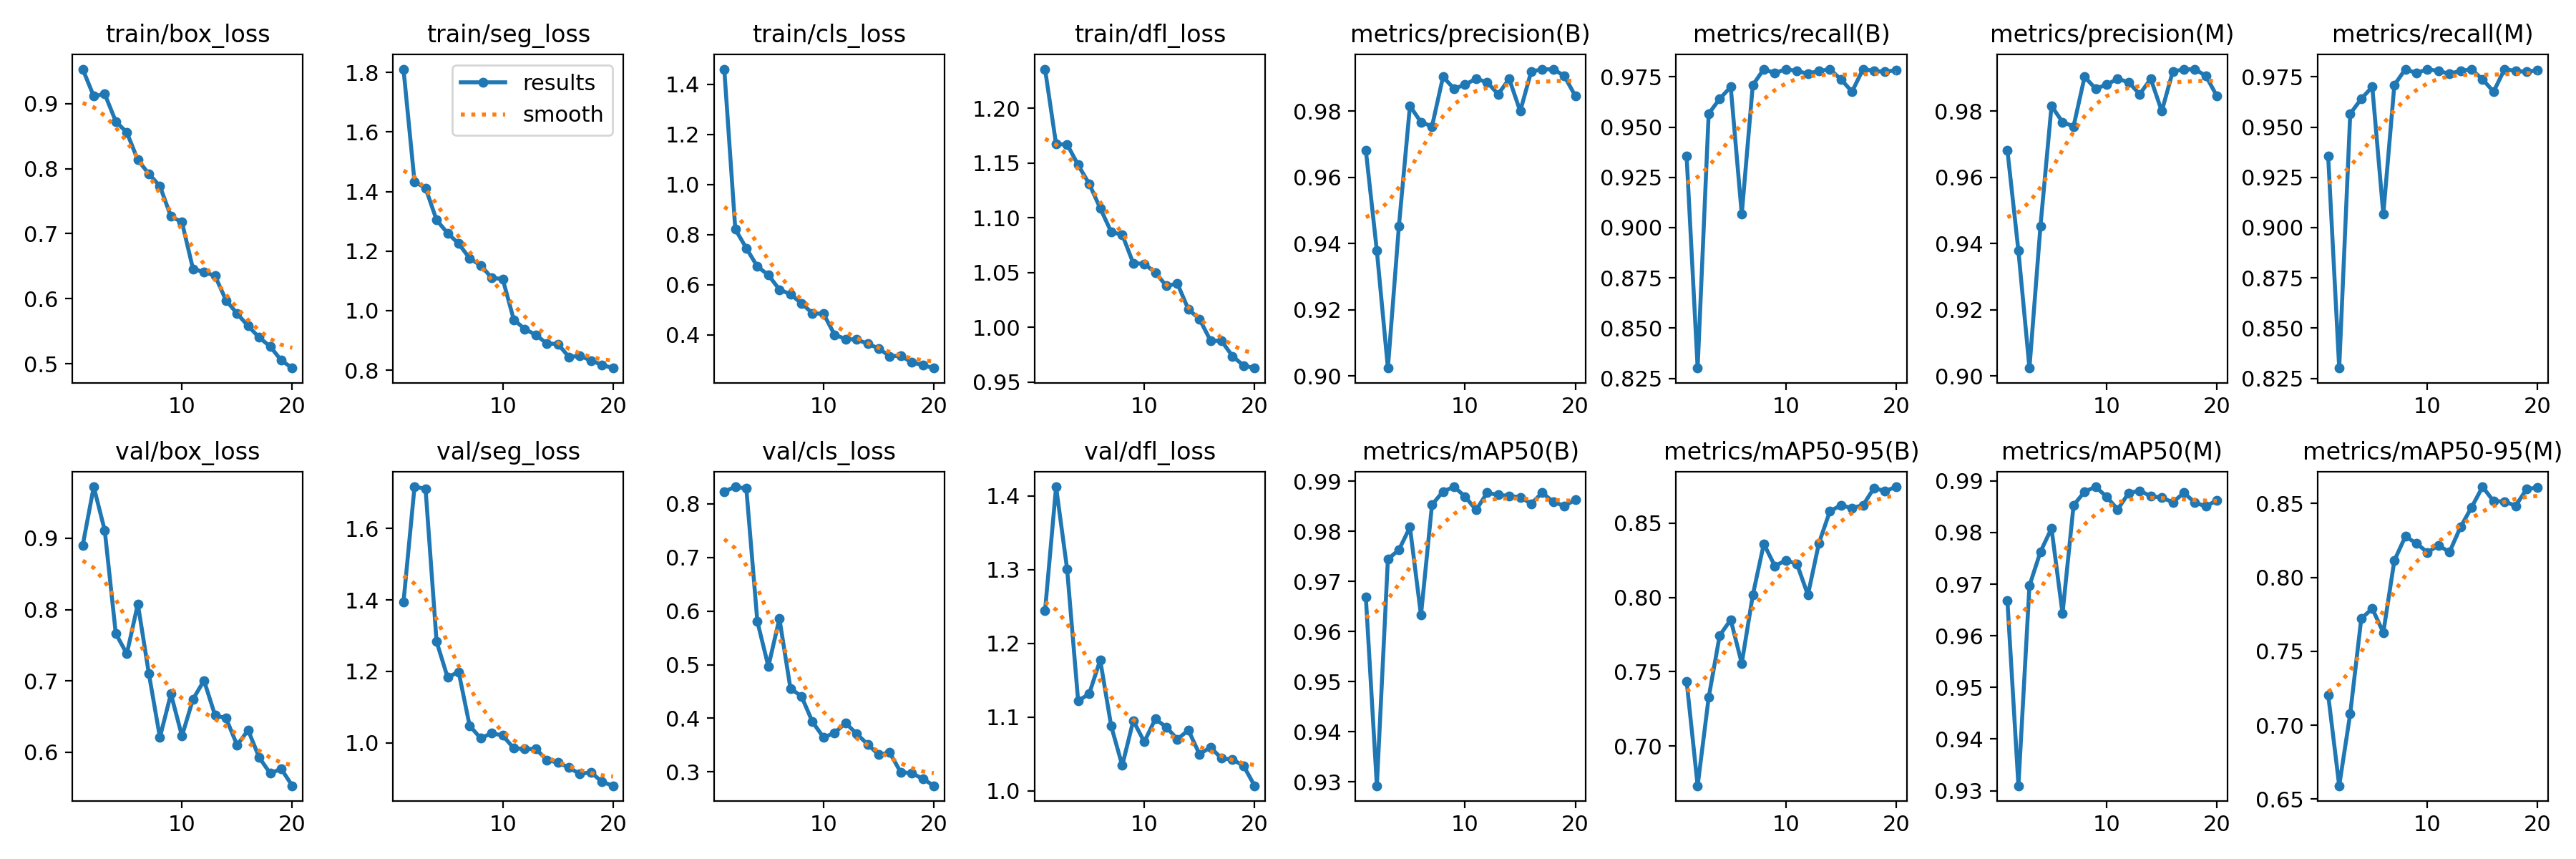

In [ ]:
# Result Graph — Display training performance graphs

import os
from IPython.display import Image, display

train_run_dir = "runs/segment/wound_seg_yolov8s"  # adjust if it auto-incremented (e.g. wound_seg_yolov8s2)
print(f"Training run folder: {train_run_dir}")
print("Contents:", os.listdir(train_run_dir))

# results.png = combined loss/metric curves across all 20 epochs
results_path = os.path.join(train_run_dir, "results.png")
if os.path.exists(results_path):
    print("\nTraining results (loss, precision, recall, mAP over epochs):")
    display(Image(filename=results_path))
else:
    print(f"Not found: {results_path}")

In [ ]:

# Validate on TEST set + get metrics

from ultralytics import YOLO

model = YOLO("runs/segment/wound_seg_yolov8s/weights/best.pt")

metrics = model.val(
    data=yaml_path,
    split="test",
    imgsz=640,
    conf=0.25,
    iou=0.6,
    plots=True,
    save_json=True
)

print("=== Box Metrics ===")
print(f"Precision:     {metrics.box.mp:.4f}")
print(f"Recall:        {metrics.box.mr:.4f}")
print(f"mAP50:         {metrics.box.map50:.4f}")
print(f"mAP50-95:      {metrics.box.map:.4f}")

print("\n=== Mask (Segmentation) Metrics ===")
print(f"Precision:     {metrics.seg.mp:.4f}")
print(f"Recall:        {metrics.seg.mr:.4f}")
print(f"mAP50:         {metrics.seg.map50:.4f}")
print(f"mAP50-95:      {metrics.seg.map:.4f}")

Ultralytics 8.3.59 🚀 Python-3.13.15 torch-2.11.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
YOLOv8s-seg summary (fused): 195 layers, 11,780,761 parameters, 0 gradients, 39.9 GFLOPs


val: Scanning /content/wound-6/test/labels... 180 images, 0 backgrounds, 0 corrupt: 100%|██████████| 180/180 [00:00<00:00, 1773.22it/s]

val: New cache created: /content/wound-6/test/labels.cache



                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95)     Mask(P          R      mAP50  mAP50-95): 100%|██████████| 12/12 [00:07<00:00,  1.59it/s]


                   all        180        180      0.999      0.994      0.995      0.896      0.999      0.994      0.995      0.884
                  mild         60         60      0.998      0.983      0.995      0.893      0.998      0.983      0.995      0.835
                normal         60         60          1          1      0.995      0.843          1          1      0.995      0.863
                severe         60         60          1          1      0.995      0.952          1          1      0.995      0.952
Speed: 0.3ms preprocess, 10.6ms inference, 0.0ms loss, 2.8ms postprocess per image
Saving runs/segment/val/predictions.json...
Results saved to runs/segment/val
=== Box Metrics ===
Precision:     0.9992
Recall:        0.9944
mAP50:         0.9949
mAP50-95:      0.8960

=== Mask (Segmentation) Metrics ===
Precision:     0.9992
Recall:        0.9944
mAP50:         0.9949
mAP50-95:      0.8836


Val run folder: runs/segment/val
Raw confusion matrix:


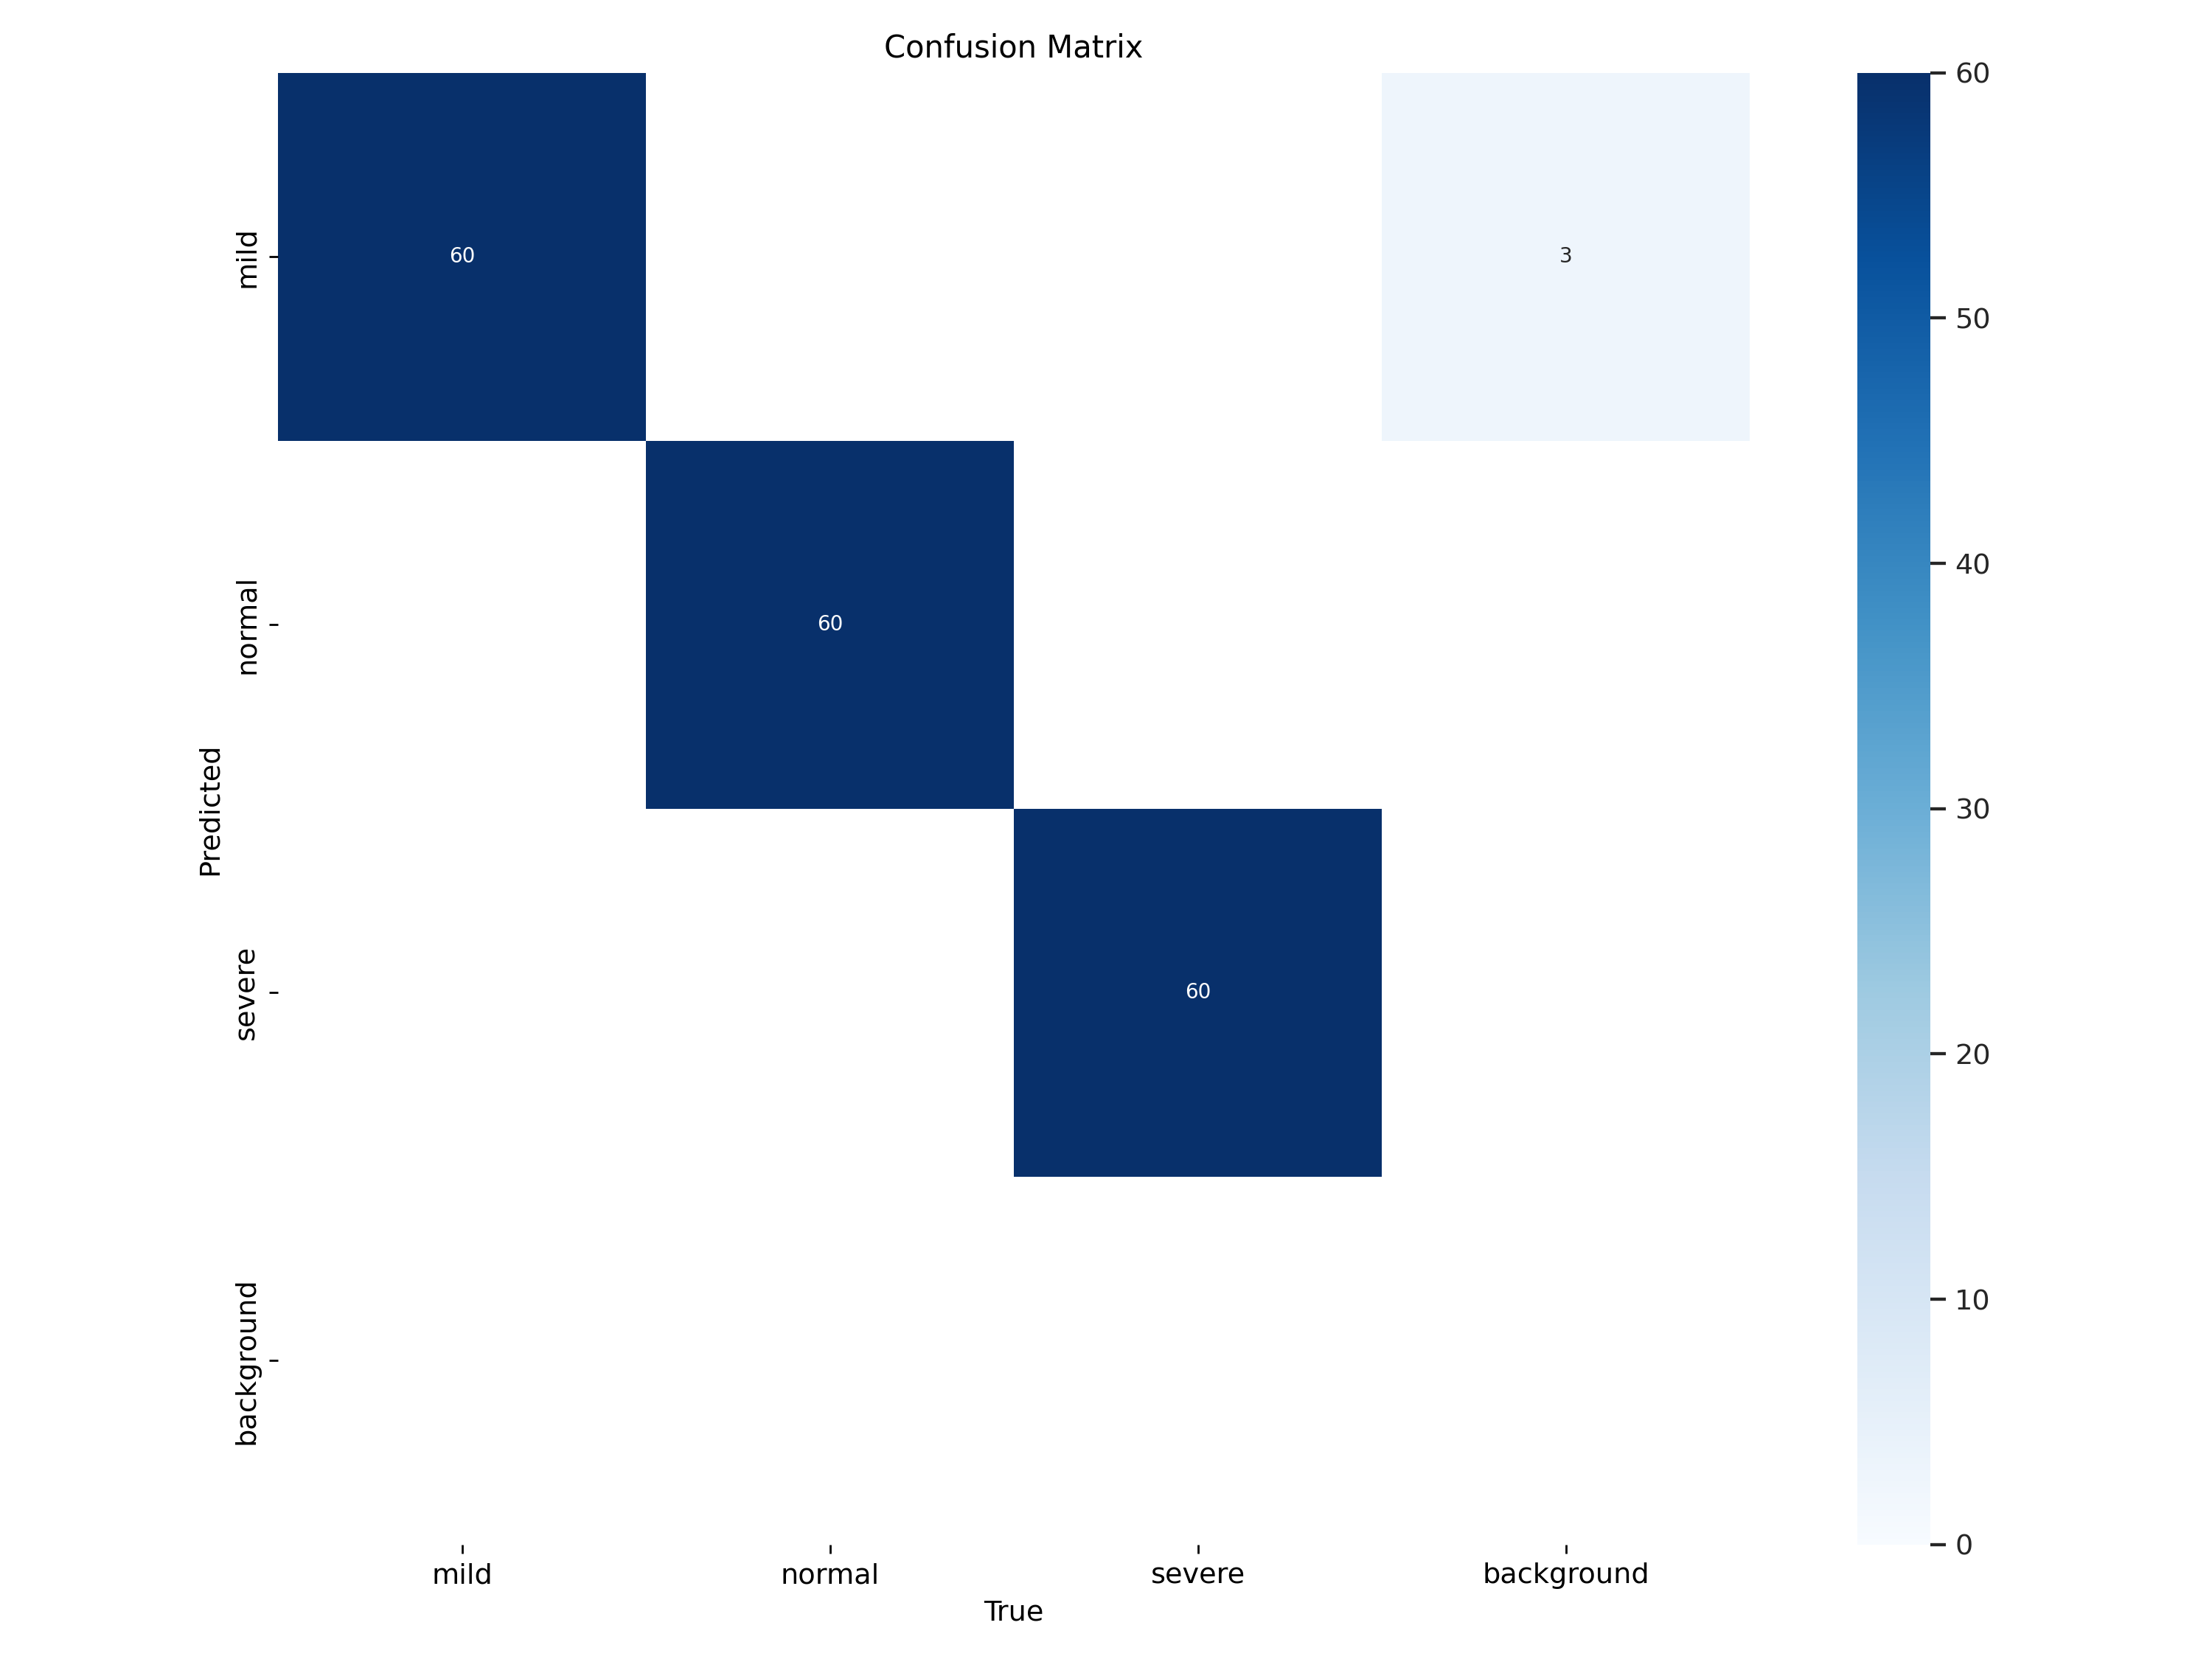

In [ ]:

# Model Evaluation - Confusion matrix

import os
from IPython.display import Image, display

val_run_dir = str(metrics.save_dir)
print(f"Val run folder: {val_run_dir}")

cm_path = os.path.join(val_run_dir, "confusion_matrix.png")
cm_norm_path = os.path.join(val_run_dir, "confusion_matrix_normalized.png")

print("Raw confusion matrix:")
display(Image(filename=cm_path))



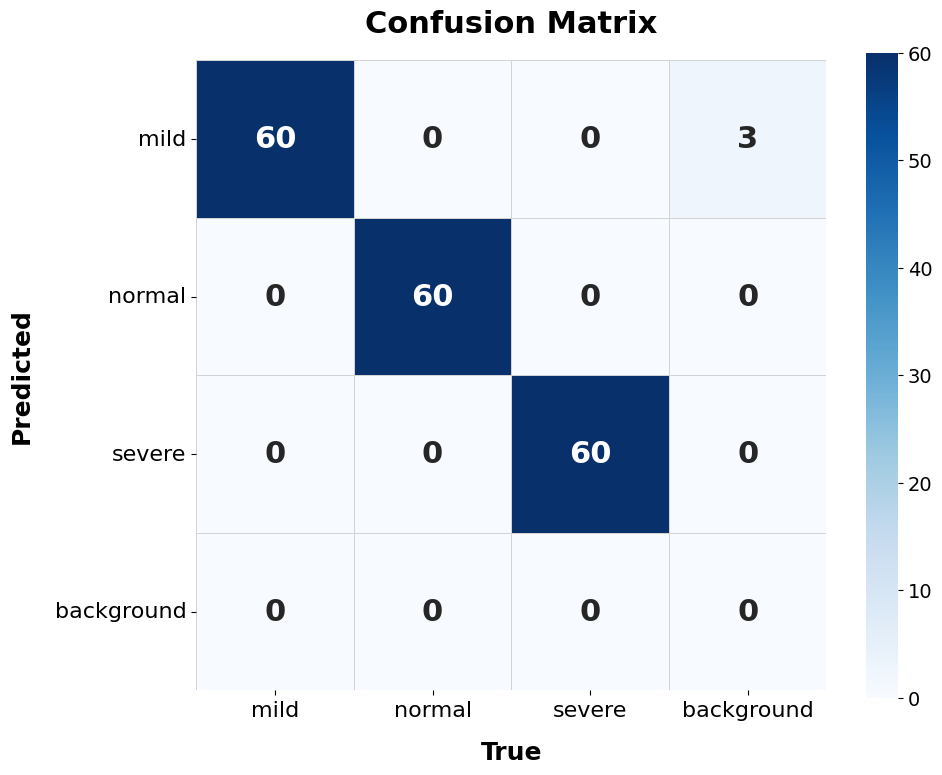

In [ ]:
# Custom confusion matrix with bigger, clearer fonts

import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

cm = metrics.confusion_matrix.matrix  # raw counts, shape (nc+1, nc+1)

class_names_list = list(data_yaml['names'].values()) if isinstance(data_yaml['names'], dict) else data_yaml['names']
labels = class_names_list + ["background"]

fig, ax = plt.subplots(figsize=(10, 8))

sns.heatmap(
    cm,
    annot=True,
    fmt='.0f',
    cmap='Blues',
    xticklabels=labels,
    yticklabels=labels,
    cbar=True,
    square=True,
    annot_kws={"size": 22, "weight": "bold"},   # bigger, bold numbers inside cells
    linewidths=0.5,
    linecolor='lightgray',
    ax=ax
)

ax.set_xlabel("True", fontsize=18, fontweight='bold', labelpad=15)
ax.set_ylabel("Predicted", fontsize=18, fontweight='bold', labelpad=15)
ax.set_title("Confusion Matrix", fontsize=22, fontweight='bold', pad=20)

ax.tick_params(axis='x', labelsize=16, rotation=0)
ax.tick_params(axis='y', labelsize=16, rotation=0)

# make colorbar tick labels bigger too
cbar = ax.collections[0].colorbar
cbar.ax.tick_params(labelsize=14)

plt.tight_layout()
plt.savefig("confusion_matrix_large_font.png", dpi=200, bbox_inches='tight')
plt.show()

In [ ]:
lbl_dir = os.path.join(root, "test", "labels")
mild_instance_count = 0
mild_image_count = 0

for lbl_file in os.listdir(lbl_dir):
    path = os.path.join(lbl_dir, lbl_file)
    if os.path.getsize(path) == 0:
        continue
    has_mild = False
    with open(path) as f:
        for line in f:
            cid = int(line.split()[0])
            if cid == class_names.index("mild") if isinstance(class_names, list) else 0:
                mild_instance_count += 1
                has_mild = True
    if has_mild:
        mild_image_count += 1

print(f"Mild: {mild_image_count} images, {mild_instance_count} instances")

Mild: 60 images, 60 instances


## Test with the Modified Mobilenet

In [ ]:
yaml_content = """
nc: 3
scales:
  n: [1.00, 1.00, 1024]

backbone:
  - [-1, 1, TorchVision, [576, 'mobilenet_v3_small', 'DEFAULT', True, 2, True]]  # 0
  - [0, 1, Index, [16, 2]]    # 1  P2 raw feature, 160x160
  - [0, 1, Index, [24, 4]]    # 2  P3 raw feature, 80x80
  - [0, 1, Index, [48, 9]]    # 3  P4 raw feature, 40x40
  - [0, 1, Index, [576, 13]]  # 4  P5 raw feature, 20x20
  - [-1, 1, SPPF, [576, 5]]                     # 5

head:
  - [-1, 1, nn.Upsample, [None, 2, 'nearest']]  # 6
  - [[-1, 3], 1, Concat, [1]]                   # 7
  - [-1, 2, C3k2, [256, False]]                 # 8

  - [-1, 1, nn.Upsample, [None, 2, 'nearest']]  # 9
  - [[-1, 2], 1, Concat, [1]]                   # 10
  - [-1, 2, C3k2, [128, False]]                 # 11

  - [-1, 1, nn.Upsample, [None, 2, 'nearest']]  # 12
  - [[-1, 1], 1, Concat, [1]]                   # 13
  - [-1, 2, C3k2, [64, False]]                  # 14

  - [-1, 1, Conv, [64, 3, 2]]                   # 15
  - [[-1, 11], 1, Concat, [1]]                  # 16
  - [-1, 2, C3k2, [128, False]]                 # 17

  - [-1, 1, Conv, [128, 3, 2]]                  # 18
  - [[-1, 8], 1, Concat, [1]]                   # 19
  - [-1, 2, C3k2, [256, False]]                 # 20

  - [-1, 1, Conv, [256, 3, 2]]                  # 21
  - [[-1, 5], 1, Concat, [1]]                   # 22
  - [-1, 2, C3k2, [576, False]]                 # 23

  - [[14, 17, 20, 23], 1, Segment, [nc, 32, 256]]  # 24
"""

with open("mobilenet_v3_small_seg.yaml", "w") as f:
    f.write(yaml_content.strip())

print("mobilenet_v3_small_seg.yaml created successfully!")

model = YOLO('mobilenet_v3_small_seg.yaml')

mobilenet_v3_small_seg.yaml created successfully!
WARNING ⚠️ no model scale passed. Assuming scale='n'.
Downloading: "https://download.pytorch.org/models/mobilenet_v3_small-047dcff4.pth" to /root/.cache/torch/hub/checkpoints/mobilenet_v3_small-047dcff4.pth


100%|██████████| 9.83M/9.83M [00:00<00:00, 137MB/s]


In [ ]:
# Train custom MobileNetV3-Small segmentation model

results_mobilenet = model.train(
    data=yaml_path,       # same dataset yaml as before (root/data.yaml)
    epochs=20,
    imgsz=640,
    batch=16,
    name="wound_seg_mobilenetv3",
    patience=20,
    plots=True
)

New https://pypi.org/project/ultralytics/8.4.140 available 😃 Update with 'pip install -U ultralytics'
Ultralytics 8.3.59 🚀 Python-3.13.15 torch-2.11.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
engine/trainer: task=segment, mode=train, model=mobilenet_v3_small_seg.yaml, data=/content/wound-6/data.yaml, epochs=20, time=None, patience=20, batch=16, imgsz=640, save=True, save_period=-1, cache=False, device=None, workers=8, project=None, name=wound_seg_mobilenetv3, exist_ok=False, pretrained=True, optimizer=auto, verbose=True, seed=0, deterministic=True, single_cls=False, rect=False, cos_lr=False, close_mosaic=10, resume=False, amp=True, fraction=1.0, profile=False, freeze=None, multi_scale=False, overlap_mask=True, mask_ratio=4, dropout=0.0, val=True, split=val, save_json=False, save_hybrid=False, conf=None, iou=0.7, max_det=300, half=False, dnn=False, plots=True, source=None, vid_stride=1, stream_buffer=False, visualize=False, augment=False, agnostic_nms=False, classes=None, retina_masks=False, e

train: Scanning /content/wound-6/train/labels.cache... 1440 images, 0 backgrounds, 0 corrupt: 100%|██████████| 1440/1440 [00:00<?, ?it/s]

albumentations: Blur(p=0.01, blur_limit=(3, 7)), MedianBlur(p=0.01, blur_limit=(3, 7)), ToGray(p=0.01, method='weighted_average', num_output_channels=3), CLAHE(p=0.01, clip_limit=(1.0, 4.0), tile_grid_size=(8, 8))



Argument(s) 'quality_lower' are not valid for transform ImageCompression
val: Scanning /content/wound-6/valid/labels.cache... 180 images, 0 backgrounds, 0 corrupt: 100%|██████████| 180/180 [00:00<?, ?it/s]


Plotting labels to runs/segment/wound_seg_mobilenetv3/labels.jpg... 
optimizer: 'optimizer=auto' found, ignoring 'lr0=0.01' and 'momentum=0.937' and determining best 'optimizer', 'lr0' and 'momentum' automatically... 
optimizer: AdamW(lr=0.001429, momentum=0.9) with parameter groups 110 weight(decay=0.0), 142 weight(decay=0.0005), 141 bias(decay=0.0)
Image sizes 640 train, 640 val
Using 2 dataloader workers
Logging results to runs/segment/wound_seg_mobilenetv3
Starting training for 20 epochs...

      Epoch    GPU_mem   box_loss   seg_loss   cls_loss   dfl_loss  Instances       Size


...

      20/20      12.9G      0.556     0.8553     0.3726      1.094         16        640: 100%|██████████| 90/90 [01:30<00:00,  1.00s/it]
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95)     Mask(P          R      mAP50  mAP50-95): 100%|██████████| 6/6 [00:03<00:00,  1.58it/s]

                   all        180        183       0.99      0.979      0.987      0.864       0.99      0.979      0.987      0.858



20 epochs completed in 0.547 hours.
Optimizer stripped from runs/segment/wound_seg_mobilenetv3/weights/last.pt, 18.1MB
Optimizer stripped from runs/segment/wound_seg_mobilenetv3/weights/best.pt, 18.1MB

Validating runs/segment/wound_seg_mobilenetv3/weights/best.pt...
Ultralytics 8.3.59 🚀 Python-3.13.15 torch-2.11.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
mobilenet_v3_small_seg summary: 437 layers, 8,787,004 parameters, 0 gradients, 167.5 GFLOPs


                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95)     Mask(P          R      mAP50  mAP50-95): 100%|██████████| 6/6 [00:06<00:00,  1.08s/it]


                   all        180        183       0.99      0.979      0.987      0.864       0.99      0.979      0.987      0.858
                  mild         60         63       0.98      0.937      0.972      0.846       0.98      0.937      0.972        0.8
                normal         60         60      0.995          1      0.995      0.833      0.995          1      0.995      0.841
                severe         60         60      0.996          1      0.995      0.913      0.996          1      0.995      0.932
Speed: 0.2ms preprocess, 13.0ms inference, 0.0ms loss, 3.3ms postprocess per image
Results saved to runs/segment/wound_seg_mobilenetv3


Training run folder: runs/segment/wound_seg_mobilenetv3
Contents: ['train_batch1.jpg', 'train_batch900.jpg', 'val_batch0_labels.jpg', 'val_batch1_pred.jpg', 'train_batch901.jpg', 'BoxP_curve.png', 'weights', 'BoxF1_curve.png', 'labels_correlogram.jpg', 'train_batch0.jpg', 'BoxPR_curve.png', 'train_batch2.jpg', 'train_batch902.jpg', 'args.yaml', 'results.csv', 'MaskF1_curve.png', 'confusion_matrix_normalized.png', 'val_batch2_pred.jpg', 'MaskR_curve.png', 'MaskP_curve.png', 'val_batch1_labels.jpg', 'BoxR_curve.png', 'val_batch2_labels.jpg', 'confusion_matrix.png', 'results.png', 'MaskPR_curve.png', 'labels.jpg', 'val_batch0_pred.jpg']

Training results (loss, precision, recall, mAP over epochs):


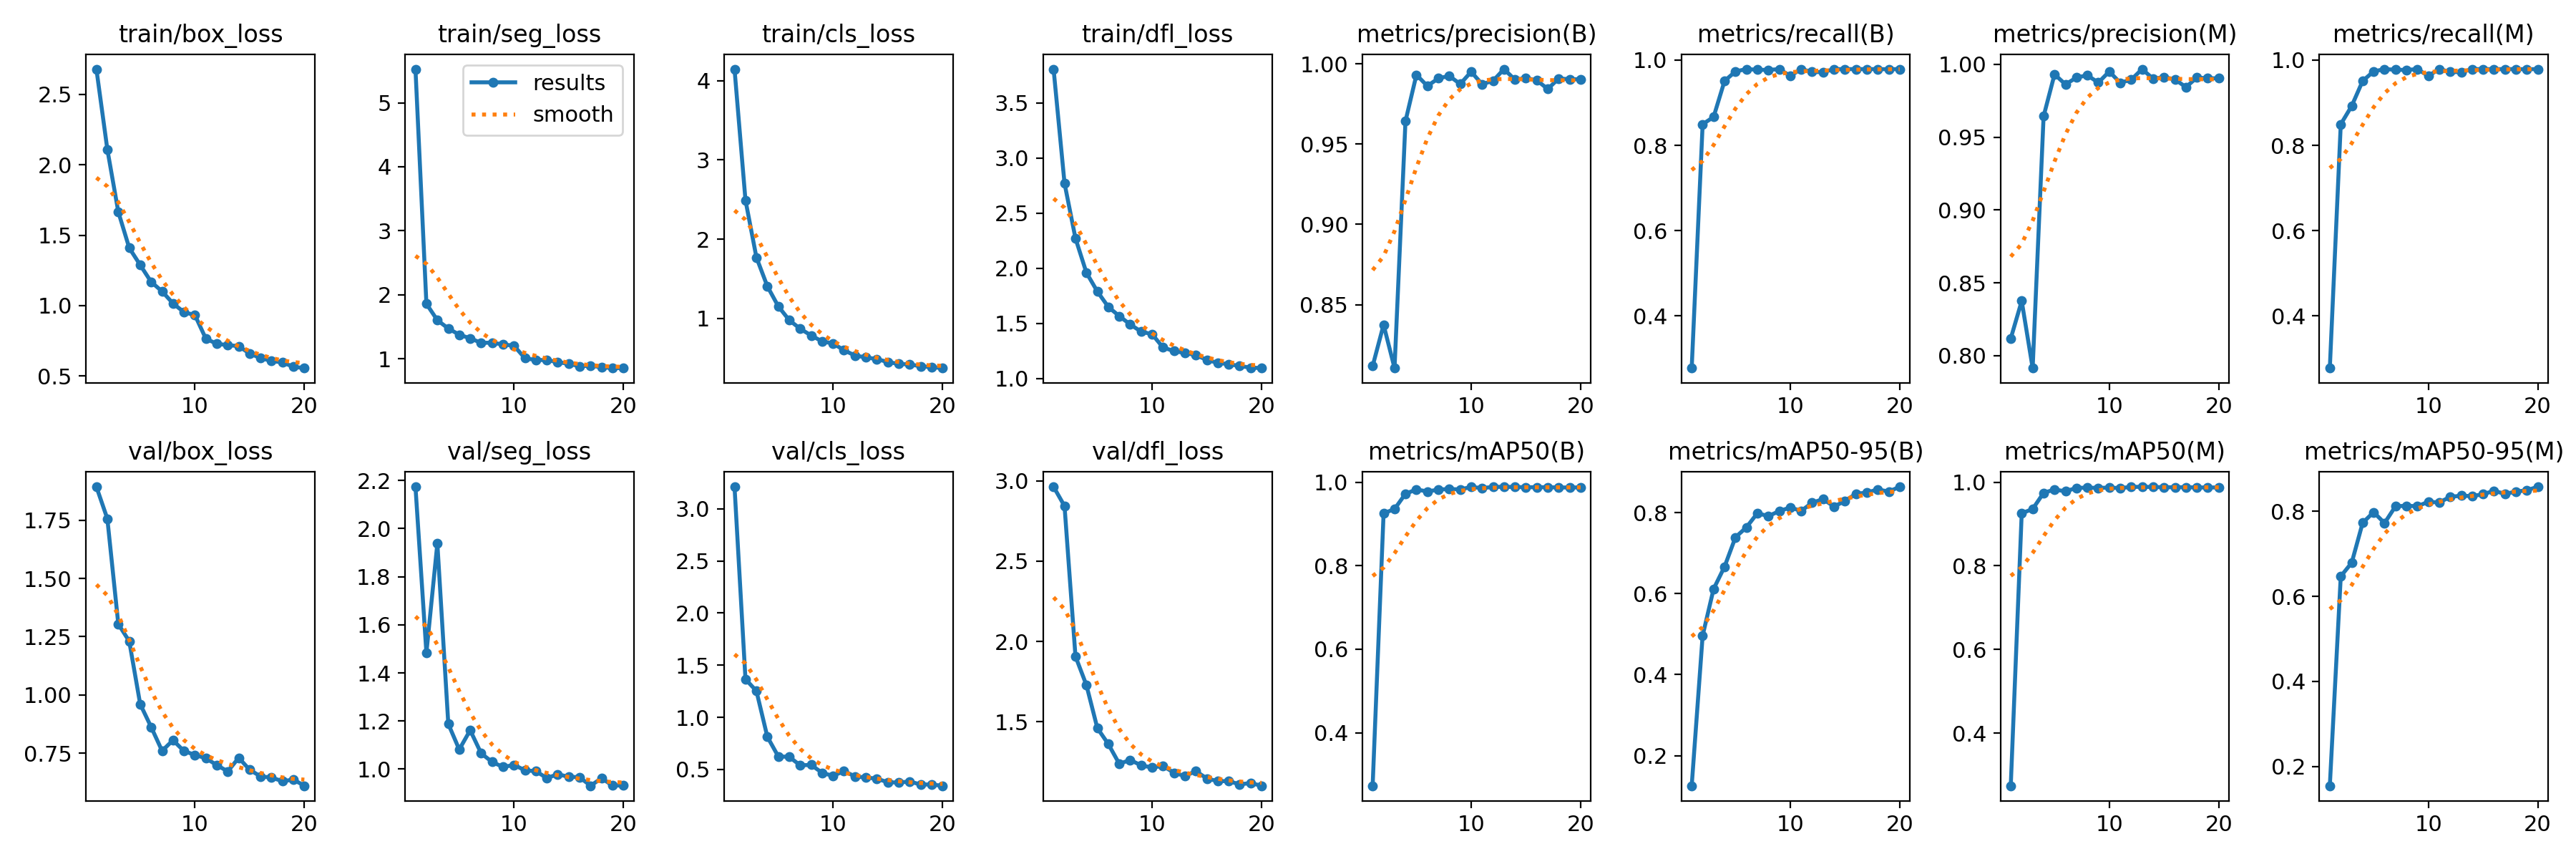

In [ ]:
#  Result - Training/validation curves for MobileNetV3-Small run

import os
from IPython.display import Image, display

train_run_dir = "runs/segment/wound_seg_mobilenetv3"  # adjust if auto-incremented (e.g. _2, _3)
print(f"Training run folder: {train_run_dir}")
print("Contents:", os.listdir(train_run_dir))

results_path = os.path.join(train_run_dir, "results.png")
if os.path.exists(results_path):
    print("\nTraining results (loss, precision, recall, mAP over epochs):")
    display(Image(filename=results_path))
else:
    print(f"Not found: {results_path}")

In [ ]:
# Validate MobileNetV3 model on TEST set

model_mobilenet = YOLO("runs/segment/wound_seg_mobilenetv3/weights/best.pt")

metrics_mobilenet = model_mobilenet.val(
    data=yaml_path,
    split="test",
    imgsz=640,
    conf=0.25,
    iou=0.6,
    plots=True,
    save_json=True
)

print("=== Box Metrics (MobileNetV3) ===")
print(f"Precision:     {metrics_mobilenet.box.mp:.4f}")
print(f"Recall:        {metrics_mobilenet.box.mr:.4f}")
print(f"mAP50:         {metrics_mobilenet.box.map50:.4f}")
print(f"mAP50-95:      {metrics_mobilenet.box.map:.4f}")

print("\n=== Mask (Segmentation) Metrics (MobileNetV3) ===")
print(f"Precision:     {metrics_mobilenet.seg.mp:.4f}")
print(f"Recall:        {metrics_mobilenet.seg.mr:.4f}")
print(f"mAP50:         {metrics_mobilenet.seg.map50:.4f}")
print(f"mAP50-95:      {metrics_mobilenet.seg.map:.4f}")

Ultralytics 8.3.59 🚀 Python-3.13.15 torch-2.11.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
mobilenet_v3_small_seg summary: 437 layers, 8,787,004 parameters, 0 gradients, 167.5 GFLOPs


val: Scanning /content/wound-6/test/labels.cache... 180 images, 0 backgrounds, 0 corrupt: 100%|██████████| 180/180 [00:00<?, ?it/s]
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95)     Mask(P          R      mAP50  mAP50-95): 100%|██████████| 12/12 [00:10<00:00,  1.14it/s]


                   all        180        180      0.999          1      0.995      0.889      0.999          1      0.995      0.883
                  mild         60         60      0.998          1      0.995      0.879      0.998          1      0.995      0.847
                normal         60         60          1          1      0.995      0.852          1          1      0.995      0.856
                severe         60         60          1          1      0.995      0.935          1          1      0.995      0.946
Speed: 0.3ms preprocess, 29.5ms inference, 0.0ms loss, 2.3ms postprocess per image
Saving runs/segment/val2/predictions.json...
Results saved to runs/segment/val2
=== Box Metrics (MobileNetV3) ===
Precision:     0.9992
Recall:        1.0000
mAP50:         0.9950
mAP50-95:      0.8888

=== Mask (Segmentation) Metrics (MobileNetV3) ===
Precision:     0.9992
Recall:        1.0000
mAP50:         0.9950
mAP50-95:      0.8834


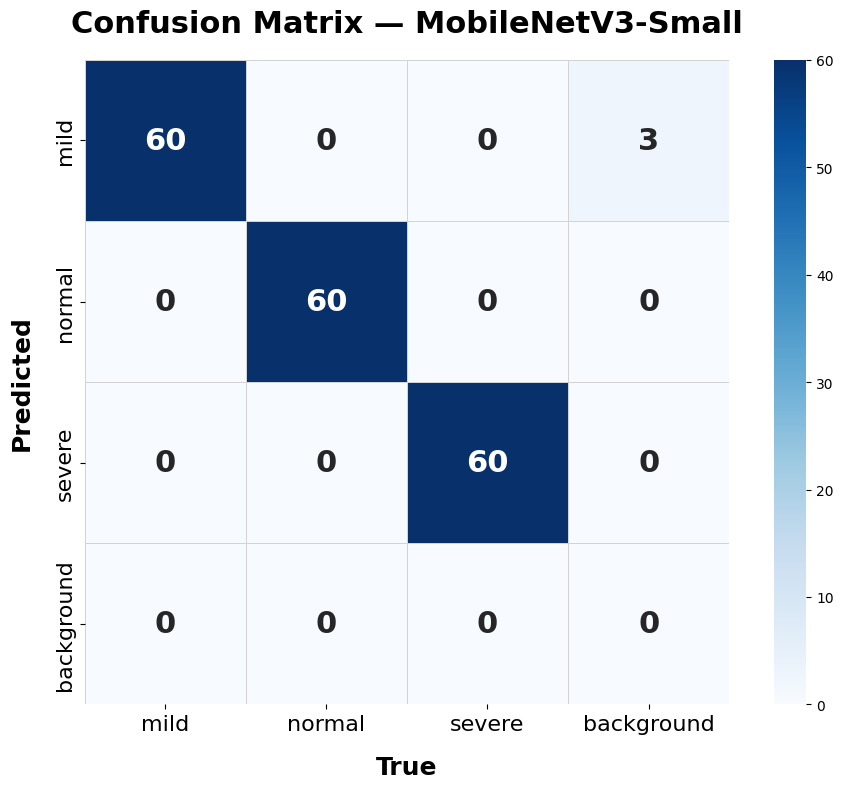

In [ ]:
# ============================================================
# CELL — Confusion matrix for MobileNetV3 (bigger font version)
# ============================================================
cm_mb = metrics_mobilenet.confusion_matrix.matrix
labels_mb = class_names_list + ["background"]

fig, ax = plt.subplots(figsize=(10, 8))
sns.heatmap(
    cm_mb, annot=True, fmt='.0f', cmap='Blues',
    xticklabels=labels_mb, yticklabels=labels_mb,
    square=True, annot_kws={"size": 22, "weight": "bold"},
    linewidths=0.5, linecolor='lightgray', ax=ax
)
ax.set_xlabel("True", fontsize=18, fontweight='bold', labelpad=15)
ax.set_ylabel("Predicted", fontsize=18, fontweight='bold', labelpad=15)
ax.set_title("Confusion Matrix — MobileNetV3-Small", fontsize=22, fontweight='bold', pad=20)
ax.tick_params(axis='x', labelsize=16)
ax.tick_params(axis='y', labelsize=16)
plt.tight_layout()
plt.savefig("confusion_matrix_mobilenet.png", dpi=200, bbox_inches='tight')
plt.show()

# Modified Shufflenet Bakcbone


In [ ]:
yaml_content = """
nc: 3
scales:
  n: [1.00, 1.00, 1024]

backbone:
  - [-1, 1, TorchVision, [1024, 'shufflenet_v2_x1_0', 'DEFAULT', True, 1, True]]  # 0
  - [0, 1, Index, [24, 4]]     # 1  P2 raw feature, 160x160
  - [0, 1, Index, [116, 5]]    # 2  P3 raw feature, 80x80
  - [0, 1, Index, [232, 6]]    # 3  P4 raw feature, 40x40
  - [0, 1, Index, [1024, 8]]   # 4  P5 raw feature, 20x20

head:
  - [-1, 1, SPPF, [1024, 5]]                    # 5

  - [-1, 1, nn.Upsample, [None, 2, 'nearest']]  # 6
  - [[-1, 3], 1, Concat, [1]]                   # 7
  - [-1, 2, C3k2, [256, False]]                 # 8

  - [-1, 1, nn.Upsample, [None, 2, 'nearest']]  # 9
  - [[-1, 2], 1, Concat, [1]]                   # 10
  - [-1, 2, C3k2, [128, False]]                 # 11

  - [-1, 1, nn.Upsample, [None, 2, 'nearest']]  # 12
  - [[-1, 1], 1, Concat, [1]]                   # 13
  - [-1, 2, C3k2, [64, False]]                  # 14

  - [-1, 1, Conv, [64, 3, 2]]                   # 15
  - [[-1, 11], 1, Concat, [1]]                  # 16
  - [-1, 2, C3k2, [128, False]]                 # 17

  - [-1, 1, Conv, [128, 3, 2]]                  # 18
  - [[-1, 8], 1, Concat, [1]]                   # 19
  - [-1, 2, C3k2, [256, False]]                 # 20

  - [-1, 1, Conv, [256, 3, 2]]                  # 21
  - [[-1, 5], 1, Concat, [1]]                   # 22
  - [-1, 2, C3k2, [1024, False]]                # 23

  - [[14, 17, 20, 23], 1, Segment, [nc, 32, 256]]  # 24
"""

with open("shufflenet_v2_seg.yaml", "w") as f:
    f.write(yaml_content.strip())

print("shufflenet_v2_seg.yaml created successfully!")

shufflenet_v2_seg.yaml created successfully!


In [ ]:

model = YOLO('shufflenet_v2_seg.yaml')

WARNING ⚠️ no model scale passed. Assuming scale='n'.
Downloading: "https://download.pytorch.org/models/shufflenetv2_x1-5666bf0f80.pth" to /root/.cache/torch/hub/checkpoints/shufflenetv2_x1-5666bf0f80.pth


100%|██████████| 8.79M/8.79M [00:00<00:00, 174MB/s]


In [ ]:
# Train custom ShuffleNetV2 segmentation model

results_shufflenet = model.train(
    data=yaml_path,       # same dataset yaml as before (root/data.yaml)
    epochs=20,
    imgsz=640,
    batch=16,
    name="wound_seg_shufflenetv2",
    patience=20,
    plots=True
)

New https://pypi.org/project/ultralytics/8.4.140 available 😃 Update with 'pip install -U ultralytics'
Ultralytics 8.3.59 🚀 Python-3.13.15 torch-2.11.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
engine/trainer: task=segment, mode=train, model=shufflenet_v2_seg.yaml, data=/content/wound-6/data.yaml, epochs=20, time=None, patience=20, batch=16, imgsz=640, save=True, save_period=-1, cache=False, device=None, workers=8, project=None, name=wound_seg_shufflenetv2, exist_ok=False, pretrained=True, optimizer=auto, verbose=True, seed=0, deterministic=True, single_cls=False, rect=False, cos_lr=False, close_mosaic=10, resume=False, amp=True, fraction=1.0, profile=False, freeze=None, multi_scale=False, overlap_mask=True, mask_ratio=4, dropout=0.0, val=True, split=val, save_json=False, save_hybrid=False, conf=None, iou=0.7, max_det=300, half=False, dnn=False, plots=True, source=None, vid_stride=1, stream_buffer=False, visualize=False, augment=False, agnostic_nms=False, classes=None, retina_masks=False, embed

train: Scanning /content/wound-6/train/labels.cache... 1440 images, 0 backgrounds, 0 corrupt: 100%|██████████| 1440/1440 [00:00<?, ?it/s]

albumentations: Blur(p=0.01, blur_limit=(3, 7)), MedianBlur(p=0.01, blur_limit=(3, 7)), ToGray(p=0.01, method='weighted_average', num_output_channels=3), CLAHE(p=0.01, clip_limit=(1.0, 4.0), tile_grid_size=(8, 8))



Argument(s) 'quality_lower' are not valid for transform ImageCompression
val: Scanning /content/wound-6/valid/labels.cache... 180 images, 0 backgrounds, 0 corrupt: 100%|██████████| 180/180 [00:00<?, ?it/s]


Plotting labels to runs/segment/wound_seg_shufflenetv2/labels.jpg... 
optimizer: 'optimizer=auto' found, ignoring 'lr0=0.01' and 'momentum=0.937' and determining best 'optimizer', 'lr0' and 'momentum' automatically... 
optimizer: AdamW(lr=0.001429, momentum=0.9) with parameter groups 132 weight(decay=0.0), 146 weight(decay=0.0005), 145 bias(decay=0.0)
Image sizes 640 train, 640 val
Using 2 dataloader workers
Logging results to runs/segment/wound_seg_shufflenetv2
Starting training for 20 epochs...

      Epoch    GPU_mem   box_loss   seg_loss   cls_loss   dfl_loss  Instances       Size


...

      20/20      13.6G     0.5507     0.8408     0.3747      1.133         16        640: 100%|██████████| 90/90 [01:36<00:00,  1.07s/it]
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95)     Mask(P          R      mAP50  mAP50-95): 100%|██████████| 6/6 [00:03<00:00,  1.66it/s]

                   all        180        183       0.99      0.974      0.987      0.857       0.99      0.974      0.987      0.857



20 epochs completed in 0.600 hours.
Optimizer stripped from runs/segment/wound_seg_shufflenetv2/weights/last.pt, 34.5MB
Optimizer stripped from runs/segment/wound_seg_shufflenetv2/weights/best.pt, 34.5MB

Validating runs/segment/wound_seg_shufflenetv2/weights/best.pt...
Ultralytics 8.3.59 🚀 Python-3.13.15 torch-2.11.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
shufflenet_v2_seg summary: 438 layers, 16,992,832 parameters, 0 gradients, 175.5 GFLOPs


                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95)     Mask(P          R      mAP50  mAP50-95): 100%|██████████| 6/6 [00:06<00:00,  1.11s/it]


                   all        180        183      0.991      0.977      0.987      0.855      0.991      0.977      0.987      0.857
                  mild         60         63      0.983      0.932      0.971      0.833      0.983      0.932      0.972      0.804
                normal         60         60      0.995          1      0.995      0.829      0.995          1      0.995      0.848
                severe         60         60      0.995          1      0.995      0.904      0.995          1      0.995      0.918
Speed: 0.3ms preprocess, 13.0ms inference, 0.0ms loss, 2.9ms postprocess per image
Results saved to runs/segment/wound_seg_shufflenetv2


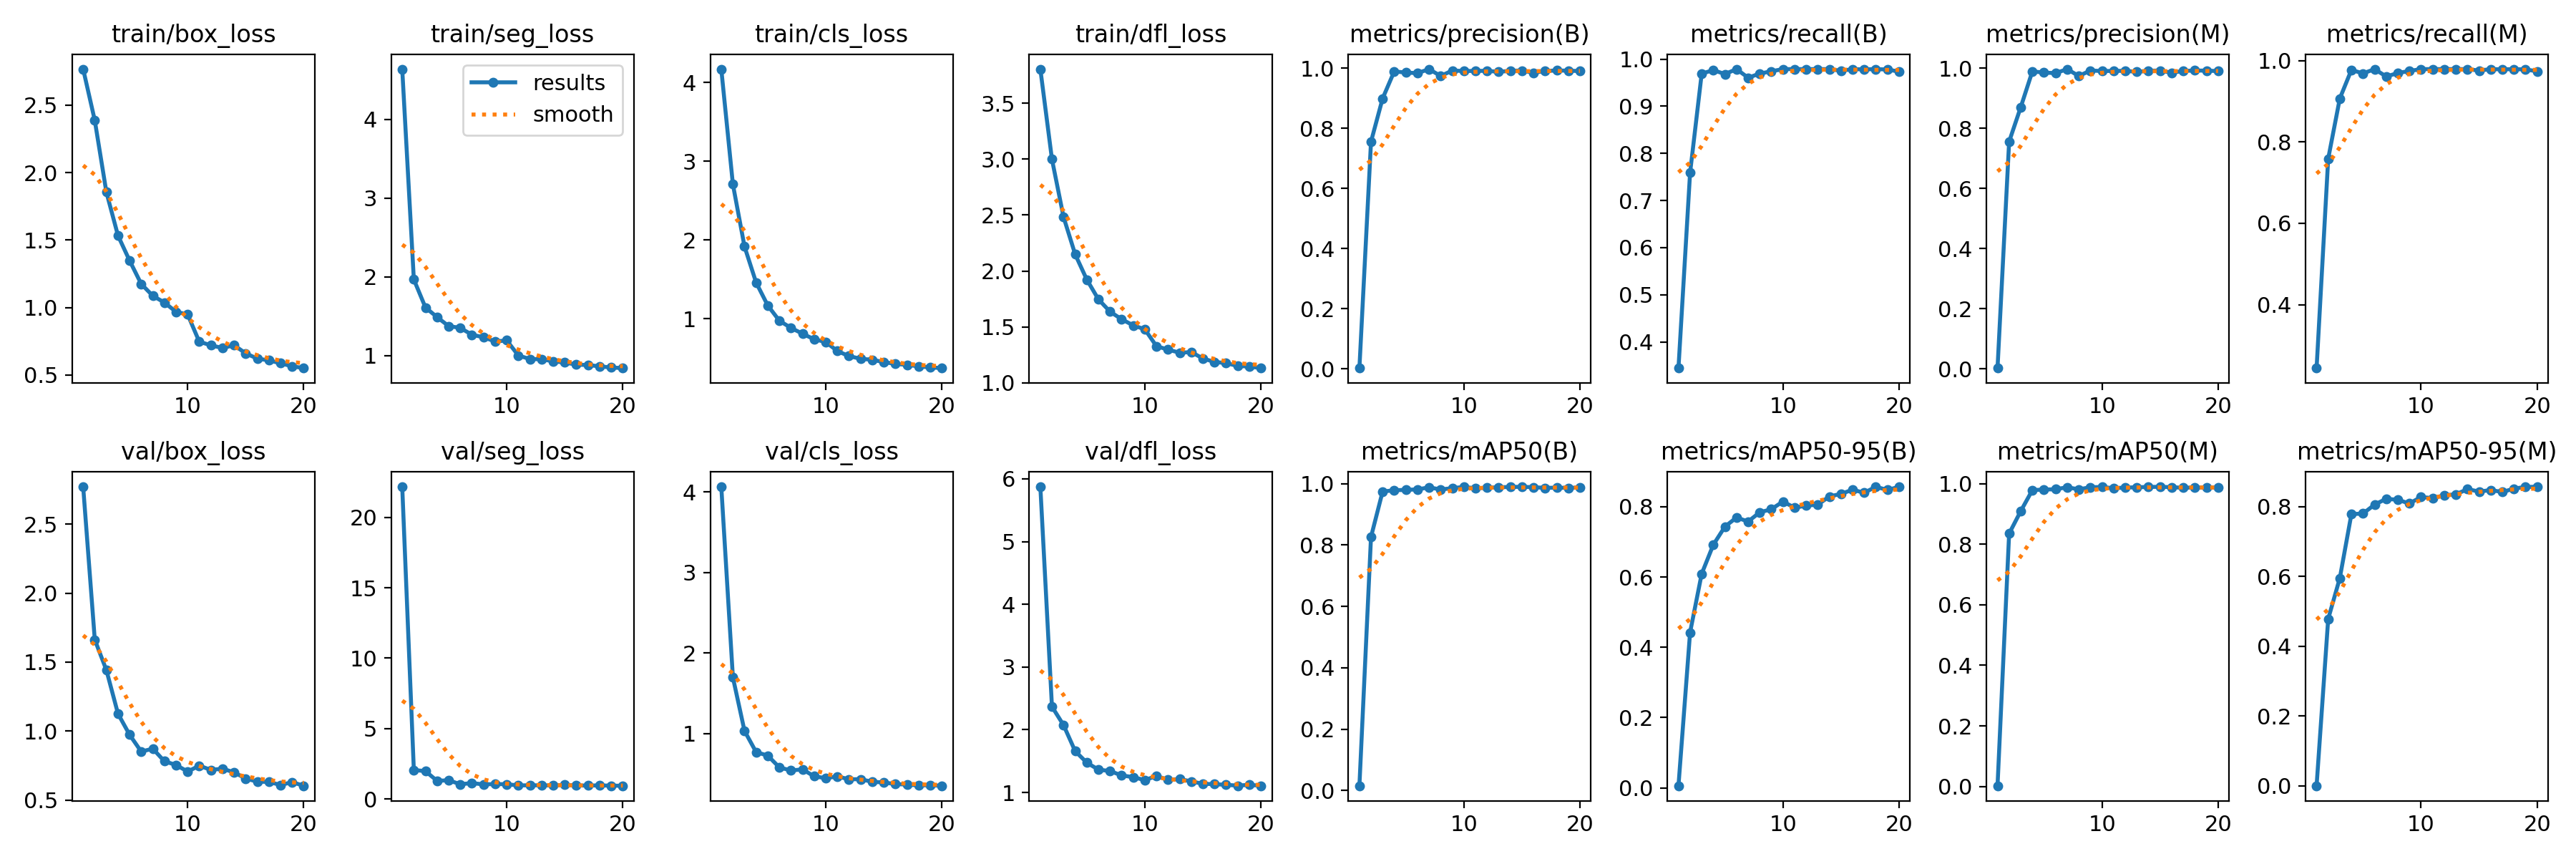

In [ ]:
from IPython.display import Image, display
display(Image(filename=os.path.join(train_run_dir, "results.png")))

In [ ]:
# Validate ShuffleNetV2 model on TEST set
model_shufflenet = YOLO("runs/segment/wound_seg_shufflenetv2/weights/best.pt")

metrics_shufflenet = model_shufflenet.val(
    data=yaml_path,
    split="test",
    imgsz=640,
    conf=0.25,
    iou=0.6,
    plots=True,
    save_json=True
)

print("=== Box Metrics (ShuffleNetV2) ===")
print(f"Precision:     {metrics_shufflenet.box.mp:.4f}")
print(f"Recall:        {metrics_shufflenet.box.mr:.4f}")
print(f"mAP50:         {metrics_shufflenet.box.map50:.4f}")
print(f"mAP50-95:      {metrics_shufflenet.box.map:.4f}")

print("\n=== Mask (Segmentation) Metrics (ShuffleNetV2) ===")
print(f"Precision:     {metrics_shufflenet.seg.mp:.4f}")
print(f"Recall:        {metrics_shufflenet.seg.mr:.4f}")
print(f"mAP50:         {metrics_shufflenet.seg.map50:.4f}")
print(f"mAP50-95:      {metrics_shufflenet.seg.map:.4f}")

Ultralytics 8.3.59 🚀 Python-3.13.15 torch-2.11.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
shufflenet_v2_seg summary: 438 layers, 16,992,832 parameters, 0 gradients, 175.5 GFLOPs


val: Scanning /content/wound-6/test/labels.cache... 180 images, 0 backgrounds, 0 corrupt: 100%|██████████| 180/180 [00:00<?, ?it/s]
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95)     Mask(P          R      mAP50  mAP50-95): 100%|██████████| 12/12 [00:09<00:00,  1.28it/s]


                   all        180        180      0.995          1      0.995      0.883      0.995          1      0.995      0.883
                  mild         60         60      0.984          1      0.995      0.873      0.984          1      0.995       0.85
                normal         60         60          1          1      0.995       0.85          1          1      0.995      0.859
                severe         60         60          1          1      0.995      0.927          1          1      0.995      0.941
Speed: 0.2ms preprocess, 29.4ms inference, 0.0ms loss, 2.0ms postprocess per image
Saving runs/segment/val3/predictions.json...
Results saved to runs/segment/val3
=== Box Metrics (ShuffleNetV2) ===
Precision:     0.9945
Recall:        1.0000
mAP50:         0.9949
mAP50-95:      0.8834

=== Mask (Segmentation) Metrics (ShuffleNetV2) ===
Precision:     0.9945
Recall:        1.0000
mAP50:         0.9949
mAP50-95:      0.8832


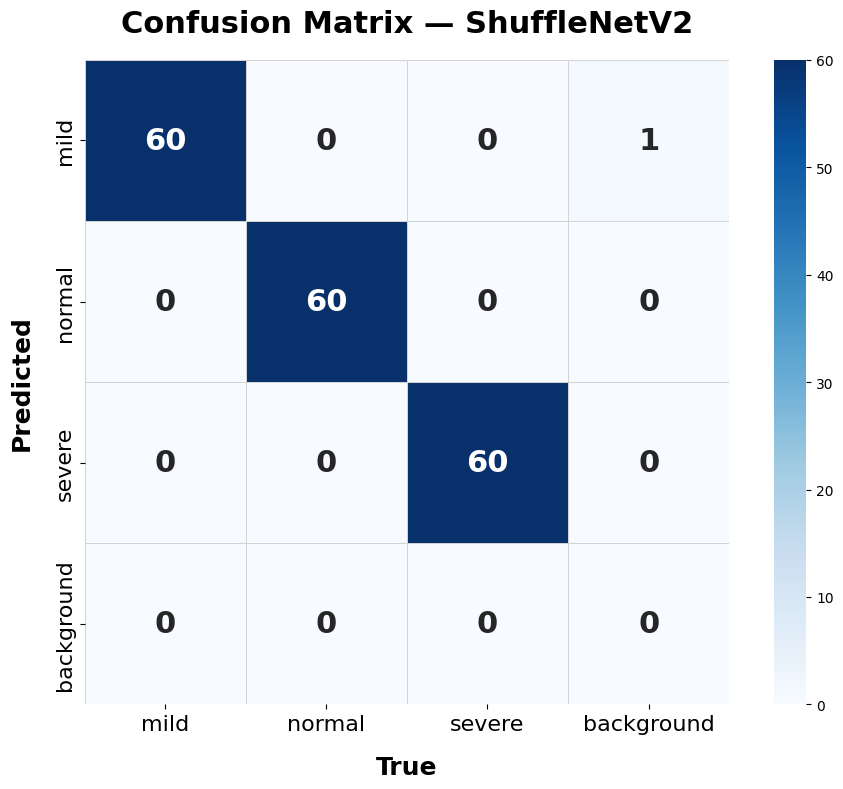

In [ ]:
# Confusion matrix for ShuffleNetV2 (bigger font version)

cm_sf = metrics_shufflenet.confusion_matrix.matrix
labels_sf = class_names_list + ["background"]

fig, ax = plt.subplots(figsize=(10, 8))
sns.heatmap(
    cm_sf, annot=True, fmt='.0f', cmap='Blues',
    xticklabels=labels_sf, yticklabels=labels_sf,
    square=True, annot_kws={"size": 22, "weight": "bold"},
    linewidths=0.5, linecolor='lightgray', ax=ax
)
ax.set_xlabel("True", fontsize=18, fontweight='bold', labelpad=15)
ax.set_ylabel("Predicted", fontsize=18, fontweight='bold', labelpad=15)
ax.set_title("Confusion Matrix — ShuffleNetV2", fontsize=22, fontweight='bold', pad=20)
ax.tick_params(axis='x', labelsize=16)
ax.tick_params(axis='y', labelsize=16)
plt.tight_layout()
plt.savefig("confusion_matrix_shufflenetv2.png", dpi=200, bbox_inches='tight')
plt.show()